*Basic Image Manipulations*

In this notebook we will cover how to perform image transformations

- Accessing and manipulating images pixels
- Image resizing
- Cropping
- Flipping


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
%matplotlib inline


Original panda image

[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


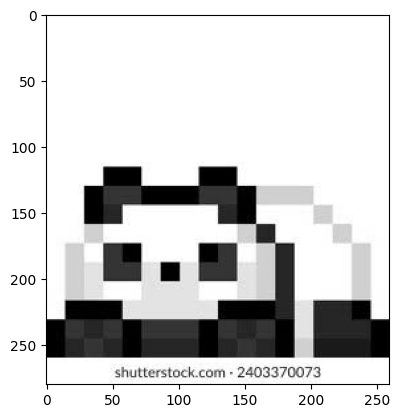

In [3]:
panda=cv2.imread("panda.jpg",0)
plt.imshow(panda,cmap="gray")
print(panda)

Accessing Individual Pixels

In [4]:
print(panda[0,0])
print(panda[250,250])

255
0


Modifying Image Pixels

[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255   0 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]
[[  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


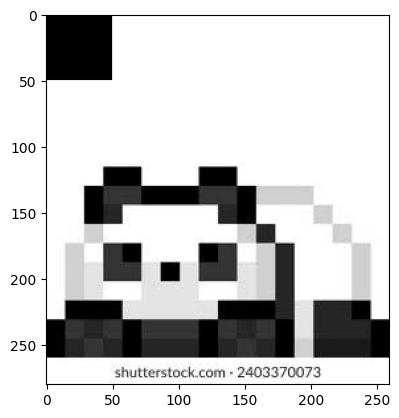

In [6]:
panda_copy=panda.copy()
panda_copy[2,2]=0
panda_copy[2,3]=0
panda_copy[3,2]=0
panda_copy[3,3]=0
plt.imshow(panda_copy,cmap="gray")
print(panda_copy)
panda_copy[0:50,0:50]=0
plt.imshow(panda_copy,cmap="gray")
print(panda_copy)

Cropping images

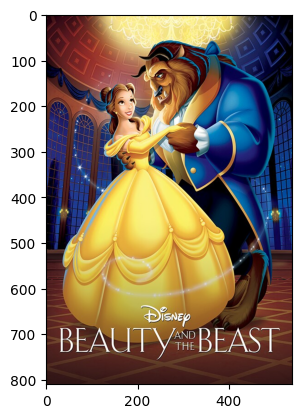

In [7]:
bb_bgr=cv2.imread("beauty_and_the_beast.jpeg",cv2.IMREAD_COLOR)
bb_rgb=bb_bgr[:,:,::-1]
plt.imshow(bb_rgb)

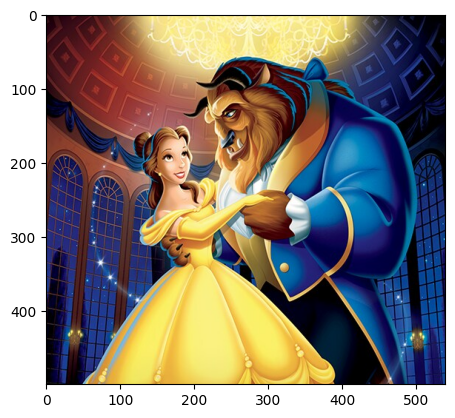

In [10]:
bb_region=bb_rgb[0:500,0:600] #specify the regions you want to crop
plt.imshow(bb_region)


*Resizing images*

- dst = resize( src, dsize[, dst[, fx[, fy[, interpolation]]]] )
- src is input image
- dsize is output image size
- fx: The scale factor along the horizontal axis (width). For example, fx=0.5 shrinks the width by half.
- fy: The scale factor along the vertical axis (height). For example, fy=2 doubles the height.
- interpolation: The method used to calculate the pixel values of the new image.
Common Interpolation Methods
Depending on whether you are shrinking or enlarging an image, different methods work best:
- cv2.INTER_NEAREST: Fastest method, but results in a pixelated/blocky look.
- cv2.INTER_LINEAR: The default method. Good for general resizing and relatively fast.
- cv2.INTER_AREA: Best choice when shrinking an image (avoids moiré patterns).
- cv2.INTER_CUBIC: Best choice when enlarging an image (slow but high quality).
- cv2.INTER_LANCZOS4: Highest quality for enlargement, but the slowest.
 



specifying scaling factors fx and fy

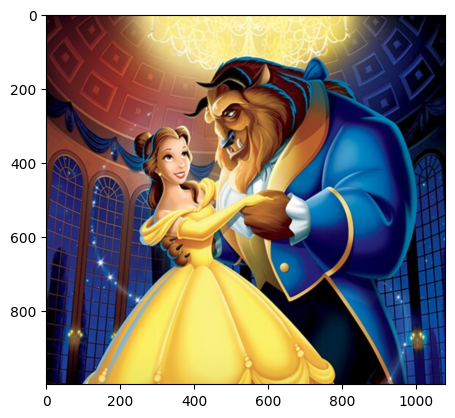

In [11]:
resize_bb=cv2.resize(bb_region,None,fx=2,fy=2) #doubling the image 2x
plt.imshow(resize_bb)

specifying the exact size of output image

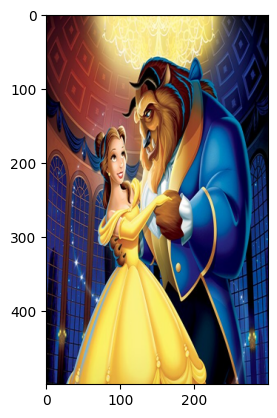

In [12]:
desired_height=500
desired_width=300
dim=(desired_width,desired_height) #the dimensions taken in 2d vector
resized_bb=cv2.resize(bb_region,dim,interpolation=cv2.INTER_AREA) #resizing the image to a specific dimension
plt.imshow(resized_bb)

Resize while maintaining aspect ratio

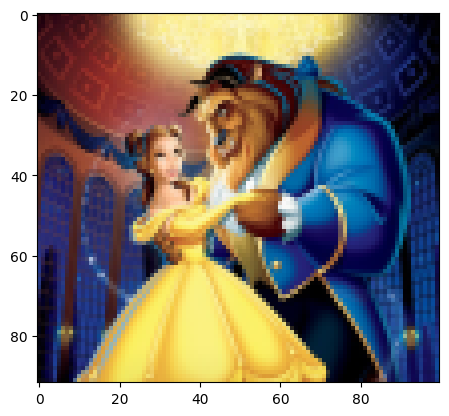

In [13]:
#using dsize
desired_width=100
aspect_ratio=desired_width/bb_region.shape[1] #calculating the aspect ratio
desired_height=int(bb_region.shape[0]*aspect_ratio) #calculating the height based on the aspect ratio
dim=(desired_width,desired_height)
resized_bb=cv2.resize(bb_region,dim,interpolation=cv2.INTER_AREA) #resizing the image to a specific dimension
plt.imshow(resized_bb)

show the cropped resized image

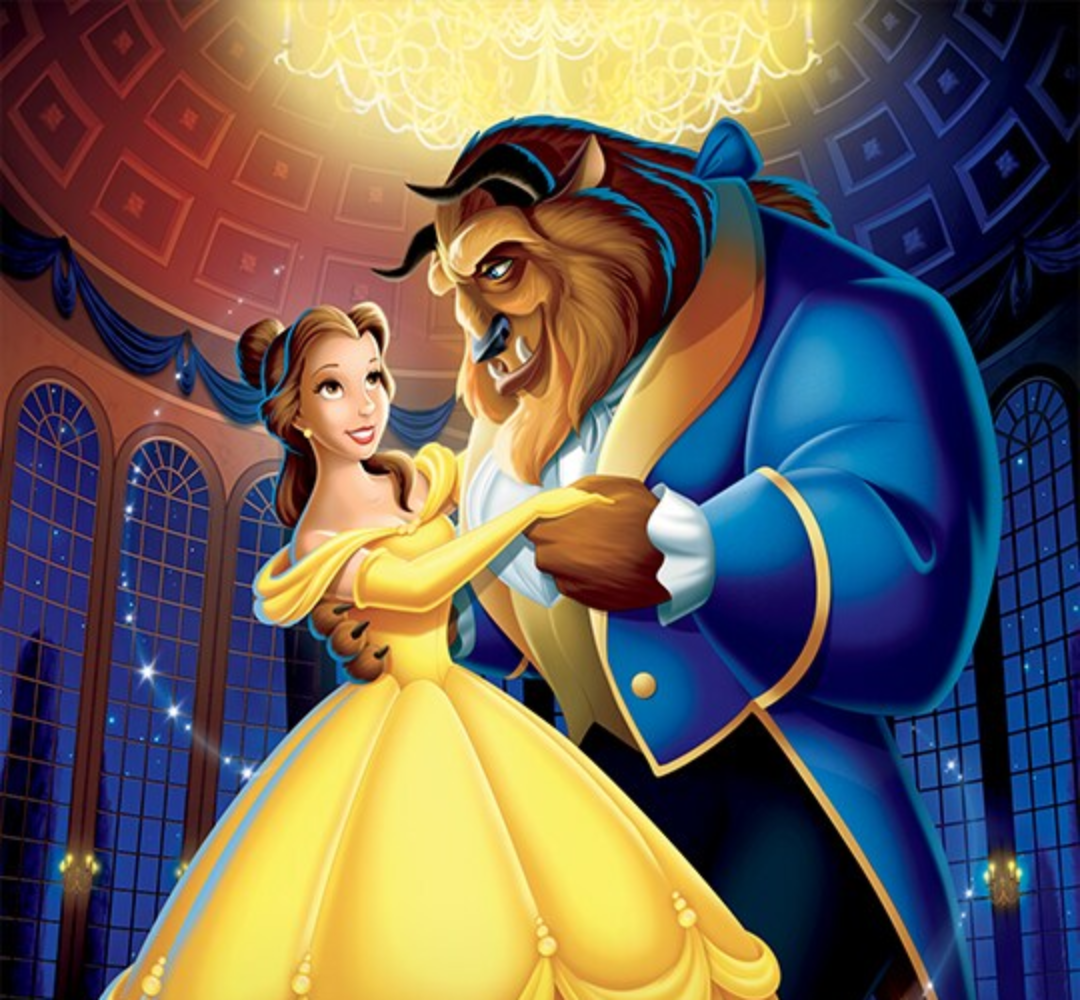

In [14]:
#swap channel order
resize_bb=resize_bb[:,:,::-1]
#save resized image to disk
cv2.imwrite("resized_bb.png",resize_bb)
#display the saved image
Image("resized_bb.png")

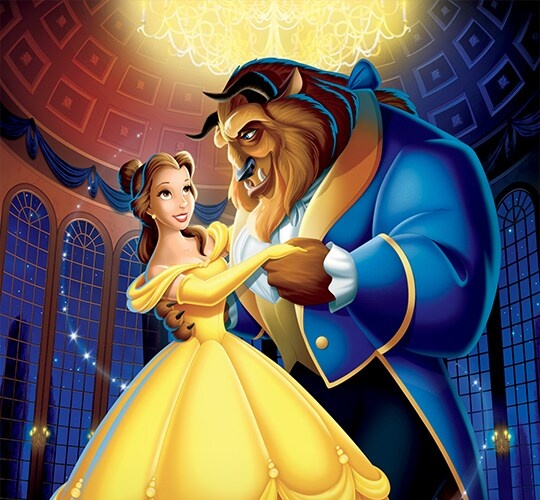

In [19]:
#swapping the channels of the image
bb_region=bb_region[:,:,::-1]
cv2.imwrite("bb_region.jpg",bb_region)
Image(filename="bb_region.jpg")

#run this again to see magic ✨

Flipping image
- dst = cv.flip( src, flipCode ) is the syntax
- flipCode is a flag to specify how to flip the array
- 0 means flipping around x axis
- 1 means flippping around y axis
- -1 means flipping both axes


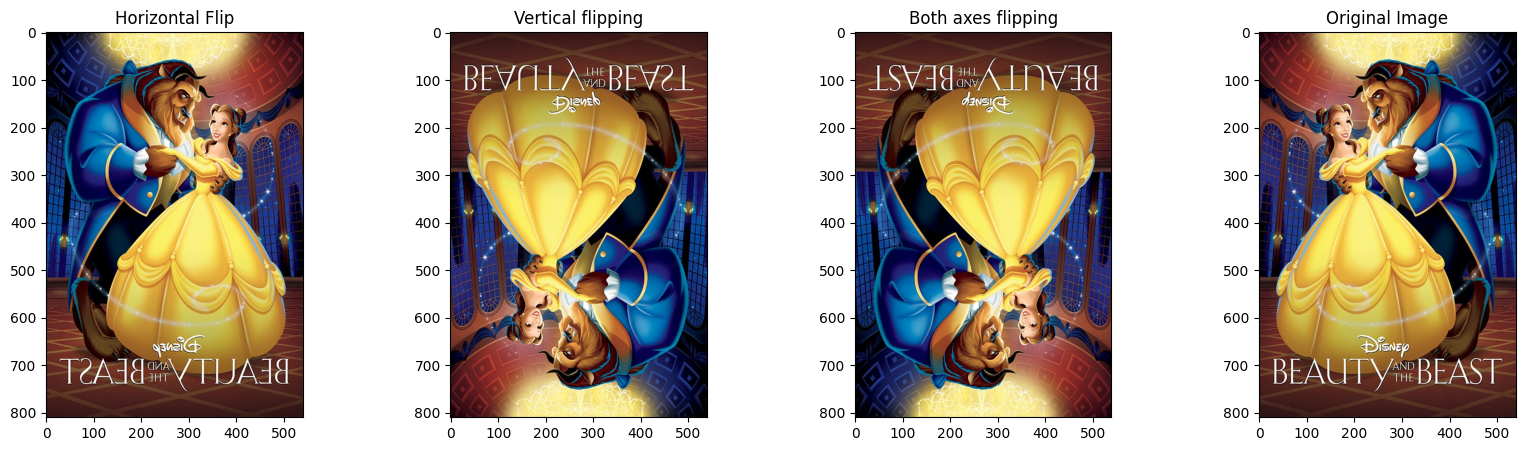

In [20]:
bb_rgb_h=cv2.flip(bb_rgb,1) #flip horizontally

bb_rgb_v=cv2.flip(bb_rgb,0) #flip vertically
bb_rgb_b=cv2.flip(bb_rgb,-1) #flip both axes
plt.figure(figsize=[20,5])
plt.subplot(141);plt.title("Horizontal Flip");plt.imshow(bb_rgb_h);
plt.subplot(142);plt.title("Vertical flipping");plt.imshow(bb_rgb_v);
plt.subplot(143);plt.title("Both axes flipping");plt.imshow(bb_rgb_b);
plt.subplot(144);plt.title("Original Image");plt.imshow(bb_rgb);


## 📝 Exercise Summary — Basic Image Manipulations

### What I Learned

- **Access pixels:** `image[row, column]` — used to read individual pixel values.
- **Modify pixels:** `image[2:4, 2:4] = 200` — used to change pixel intensity.
- **Crop an image:** `cropped = image[200:400, 300:600]` — used to extract a specific region of interest (ROI).
- **Resize an image:** `cv2.resize(image, None, fx=2, fy=2)` — used to increase or decrease image size.
- **Resize to exact dimensions:** `cv2.resize(image, (width, height))` — useful when a fixed image size is required.
- **Maintain aspect ratio:** prevents the image from becoming stretched or distorted.
- **Flip an image:** `cv2.flip(image, 1)` → horizontal, `cv2.flip(image, 0)` → vertical, `cv2.flip(image, -1)` → both axes.
- **Why important:** These are basic image preprocessing and transformation techniques used in Computer Vision and Machine Learning.

### Practical Experiment

- 🐼 **Panda image** — used for pixel manipulation and cropping.
- 🏰 **Beauty and the Beast image** — used for resizing and flipping.

### Key Takeaway

> An image is a NumPy array of pixels, and OpenCV allows us to manipulate and transform those pixels.